# Advanced Multi-Parameter Vehicle Model Calibration

This notebook performs comprehensive parameter estimation using ALL 7 trajectory files.

## Key Improvements over Previous Approach:
1. **Uses ALL 7 CSV trajectories** with shorter segment length
2. **Optimizes 10+ parameters** including:
   - Tire inertia (`Inertia_tire`) - critical for wheel deceleration
   - Tire radius (`radius_tire`) - affects slip and torque
   - Magic Tire Formula params (`c_1x`, `c_2x`, `C_x`, `E_x`)
   - Rolling resistance (`C_roll1`, `C_roll2`)
   - Friction, air resistance, mass
3. **Uses weighted loss** emphasizing wheel speeds and velocities
4. **Multi-stage optimization** for better convergence

## Analysis of Simulator Code:
The key equations for tire dynamics are:
```
dtire_rate = (drive_torque - resistance_torque) / Inertia_tire
resistance_torque = F_x_tire * radius_tire + roll_resistance + break_torque
```
So `Inertia_tire` directly controls how fast wheels respond to braking!

In [1]:
import sys
import os
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import jax.lax as lax
from scipy.optimize import differential_evolution, minimize, dual_annealing
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import glob
import copy

# Import project modules
from simulation.VehicleModel import (
    default_params as original_default_params,
    vehicle_RK4x,
    vehicle_fy,
    radius_tire as original_radius_tire,
)
from utils.real_data import (
    prep_x_obs_from_df,
    make_controls_from_df,
    initial_state_from_obs,
)

print("✓ Imports successful")
print(f"JAX devices: {jax.devices()}")

# Print original default parameters
print("\nOriginal default_params:")
for k, v in original_default_params.items():
    print(f"  {k}: {v}")

c:\Users\aritr\anaconda3\envs\sbi_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports successful
JAX devices: [CpuDevice(id=0)]

Original default_params:
  c_1x: 25000000.0
  c_2x: 3600000.0
  c_1y: 1900000.0
  c_2y: 135000.0
  C_x: 1.42
  C_y: 1.9
  E_x: -9.75
  E_y: 0.52
  C_roll1: 0.0083
  C_roll2: 0.0005
  mass: 1720
  Inertia_z: 2066
  Inertia_tire: 28.6
  Inertia_engine: 0.197
  air_resistance: 0.27
  dt: 0.01


## 1. Load ALL 7 Trajectory Files

In [2]:
# Path to measurements directory
data_dir = Path("../../data/measurements")

# Find all CSV files
csv_files = sorted(glob.glob(str(data_dir / "*.csv")))

print(f"Found {len(csv_files)} CSV files:")
for i, f in enumerate(csv_files, 1):
    fname = Path(f).name
    df_temp = pd.read_csv(f)
    print(f"  {i}. {fname}: {len(df_temp)} rows")

# Find minimum length to include ALL files
min_length = min(len(pd.read_csv(f)) for f in csv_files)
print(f"\nMinimum file length: {min_length} rows")

Found 7 CSV files:
  1. Jeversen_2021_12_15_112145_Asphalt-Vollbremsung.csv: 1070 rows
  2. Jeversen_2021_12_15_112328_Asphalt-Vollbremsung.csv: 1436 rows
  3. Jeversen_2021_12_15_125650_Beton-Vollbremsung.csv: 1189 rows
  4. Jeversen_2021_12_15_125936_Beton-Vollbremsung.csv: 1263 rows
  5. Jeversen_2021_12_15_134709_Basalt-Vollbremsung.csv: 1377 rows
  6. Jeversen_2021_12_15_134858_Basalt-Vollbremsung.csv: 1356 rows
  7. Jeversen_2022_10_12_110132.csv: 3165 rows

Minimum file length: 1070 rows


In [3]:
# Configuration - use shorter segments to include ALL files
T_SEG = 900  # Use 900 timesteps (9 seconds) to fit all files
START_OFFSET = 50  # Skip first 50 timesteps

print(f"Configuration:")
print(f"  T_SEG: {T_SEG} timesteps ({T_SEG * 0.01:.1f} seconds)")
print(f"  START_OFFSET: {START_OFFSET} timesteps")
print(f"  Required rows: {START_OFFSET + T_SEG} = {START_OFFSET + T_SEG}")
print(f"  Min available: {min_length}")
print(f"  ✓ All files can be used!" if min_length >= START_OFFSET + T_SEG else "✗ Some files too short")

Configuration:
  T_SEG: 900 timesteps (9.0 seconds)
  START_OFFSET: 50 timesteps
  Required rows: 950 = 950
  Min available: 1070
  ✓ All files can be used!


In [4]:
# Load all dataframes
dataframes = {}
for csv_path in csv_files:
    fname = Path(csv_path).stem
    df = pd.read_csv(csv_path)
    dataframes[fname] = df

# Extract trajectories from ALL files
trajectories = []

for fname, df in dataframes.items():
    n_rows = len(df)
    
    if n_rows < START_OFFSET + T_SEG:
        print(f"⚠ {fname}: only {n_rows} rows, adjusting segment...")
        # Use maximum available
        actual_start = max(0, min(START_OFFSET, n_rows - 500))
        actual_T = min(T_SEG, n_rows - actual_start)
    else:
        actual_start = START_OFFSET
        actual_T = T_SEG
    
    try:
        x_obs = prep_x_obs_from_df(
            df,
            start_idx=actual_start,
            T=actual_T,
            rate_body_z_in_deg_s=True,
            tire_rates_in_rpm=True,
            vel_body_in_kmh=True,
        )
        
        controls = make_controls_from_df(
            df,
            start_idx=actual_start,
            T=actual_T,
            steer_in_deg=True,
        )
        
        y0 = x_obs[0].numpy()
        state0 = initial_state_from_obs(y0)
        
        # Identify surface type from filename
        if "Asphalt" in fname:
            surface = "asphalt"
        elif "Beton" in fname:
            surface = "concrete"
        elif "Basalt" in fname:
            surface = "basalt"
        else:
            surface = "unknown"
        
        trajectories.append({
            'name': fname,
            'surface': surface,
            'x_obs': x_obs.numpy(),
            'controls': controls,
            'state0': state0,
            'T': actual_T,
        })
        
        print(f"✓ {fname}: {actual_T} steps, surface={surface}")
        
    except Exception as e:
        print(f"✗ Error processing {fname}: {e}")

print(f"\n✓ Successfully extracted {len(trajectories)} trajectories (ALL 7 files!)")

✓ Jeversen_2021_12_15_112145_Asphalt-Vollbremsung: 900 steps, surface=asphalt
✓ Jeversen_2021_12_15_112328_Asphalt-Vollbremsung: 900 steps, surface=asphalt
✓ Jeversen_2021_12_15_125650_Beton-Vollbremsung: 900 steps, surface=concrete
✓ Jeversen_2021_12_15_125936_Beton-Vollbremsung: 900 steps, surface=concrete
✓ Jeversen_2021_12_15_134709_Basalt-Vollbremsung: 900 steps, surface=basalt
✓ Jeversen_2021_12_15_134858_Basalt-Vollbremsung: 900 steps, surface=basalt
✓ Jeversen_2022_10_12_110132: 900 steps, surface=unknown

✓ Successfully extracted 7 trajectories (ALL 7 files!)


## 2. Create Custom Simulator with Tunable Parameters

We need to create a version of the rollout function that accepts all parameters we want to tune.

In [5]:
# Import necessary functions for custom rollout
from simulation.VehicleModel import (
    MTF_x, MTF_y,
    static_tire_load,
    tire_velocity, tire_slip,
    gravitation, air_density, body_surface_x,
    width_front, width_rear, length_front, length_rear,
    height_CoG,
)
from simulation.utils import R_z, rotate_2D_Vector

# Define which parameters we'll optimize
PARAM_NAMES = [
    'mu',           # 0: friction coefficient
    'cd',           # 1: air resistance (C_d)
    'mass',         # 2: vehicle mass
    'Inertia_tire', # 3: tire inertia (critical for braking!)
    'radius_tire',  # 4: tire radius
    'c_1x',         # 5: MTF longitudinal stiffness
    'c_2x',         # 6: MTF longitudinal param
    'C_x',          # 7: MTF shape factor
    'E_x',          # 8: MTF curvature factor
    'C_roll1',      # 9: rolling resistance 1
    'C_roll2',      # 10: rolling resistance 2
]

# Default values and bounds for each parameter
PARAM_DEFAULTS = {
    'mu': 1.0,
    'cd': 0.27,
    'mass': 1720.0,
    'Inertia_tire': 28.6,
    'radius_tire': 0.3116,
    'c_1x': 2.5e7,
    'c_2x': 3.6e6,
    'C_x': 1.42,
    'E_x': -9.75,
    'C_roll1': 0.0083,
    'C_roll2': 0.0005,
}

PARAM_BOUNDS = {
    'mu': (0.3, 1.5),           # Friction: can be quite low on wet surfaces
    'cd': (0.15, 0.80),         # Air resistance: wider range
    'mass': (1600.0, 2200.0),   # Mass
    'Inertia_tire': (5.0, 60.0),  # Tire inertia: WIDE range - this is key!
    'radius_tire': (0.28, 0.38),  # Tire radius: ~10% variation
    'c_1x': (1e6, 5e7),         # MTF params: wide range
    'c_2x': (1e5, 1e7),
    'C_x': (0.8, 2.5),
    'E_x': (-15.0, 0.0),
    'C_roll1': (0.001, 0.02),
    'C_roll2': (0.0001, 0.002),
}

print("Parameters to optimize:")
for name in PARAM_NAMES:
    lo, hi = PARAM_BOUNDS[name]
    default = PARAM_DEFAULTS[name]
    print(f"  {name:15s}: default={default:12.4g}, bounds=[{lo:10.3g}, {hi:10.3g}]")

Parameters to optimize:
  mu             : default=           1, bounds=[       0.3,        1.5]
  cd             : default=        0.27, bounds=[      0.15,        0.8]
  mass           : default=        1720, bounds=[   1.6e+03,    2.2e+03]
  Inertia_tire   : default=        28.6, bounds=[         5,         60]
  radius_tire    : default=      0.3116, bounds=[      0.28,       0.38]
  c_1x           : default=     2.5e+07, bounds=[     1e+06,      5e+07]
  c_2x           : default=     3.6e+06, bounds=[     1e+05,      1e+07]
  C_x            : default=        1.42, bounds=[       0.8,        2.5]
  E_x            : default=       -9.75, bounds=[       -15,          0]
  C_roll1        : default=      0.0083, bounds=[     0.001,       0.02]
  C_roll2        : default=      0.0005, bounds=[    0.0001,      0.002]


In [6]:
def create_custom_params(opt_params_array):
    """
    Create a full params dict from the optimization array.
    
    Args:
        opt_params_array: array of optimized parameters in PARAM_NAMES order
    
    Returns:
        params dict compatible with vehicle model
    """
    # Start with original defaults
    params = copy.deepcopy(original_default_params)
    
    # Update with optimized values
    params['air_resistance'] = opt_params_array[1]  # cd
    params['mass'] = opt_params_array[2]
    params['Inertia_tire'] = opt_params_array[3]
    params['c_1x'] = opt_params_array[5]
    params['c_2x'] = opt_params_array[6]
    params['C_x'] = opt_params_array[7]
    params['E_x'] = opt_params_array[8]
    params['C_roll1'] = opt_params_array[9]
    params['C_roll2'] = opt_params_array[10]
    
    # Also return special params
    mu = opt_params_array[0]
    radius = opt_params_array[4]
    
    return params, mu, radius


def custom_vehicle_dx(veh_state, aux_input, mu, radius_tire, params):
    """
    Custom vehicle dynamics with tunable parameters.
    Based on vehicle_dx from VehicleModel.py but with modifiable radius_tire.
    """
    # Unpack parameters
    air_resistance = params["air_resistance"]
    mass = params["mass"]
    Inertia_z = params["Inertia_z"]
    Inertia_tire = params["Inertia_tire"]
    Inertia_engine = params["Inertia_engine"]
    C_roll1 = params["C_roll1"]
    C_roll2 = params["C_roll2"]

    # Unpack state
    yaw = veh_state[2]
    dyaw = veh_state[3]
    veh_vel = veh_state[4:6]
    tire_rate = veh_state[6:10]

    # Unpack aux input
    steer_ang = aux_input["steer_ang"]
    steer_ang = jnp.array([steer_ang, steer_ang, 0, 0])
    engine_torque = aux_input["engine_torque"]
    engine_torque = jnp.array([engine_torque / 2, engine_torque / 2, 0, 0])
    break_torque = aux_input["break_torque"]
    break_torque = jnp.array([break_torque, break_torque, break_torque, break_torque])
    gear_transmission = aux_input["gear_transmission"]
    gear_transmission = jnp.array([gear_transmission, gear_transmission, 0, 0])

    # Contact forces with custom radius
    vel_tire = tire_velocity(veh_vel[0], veh_vel[1], dyaw, steer_ang)
    
    # Custom tire slip calculation with tunable radius
    vel_limit = 1.0
    v_reg = jnp.maximum(jnp.abs(vel_tire[:, 0]), vel_limit)
    s_x = (tire_rate * radius_tire - vel_tire[:, 0]) / v_reg
    s_y = -vel_tire[:, 1] / v_reg
    
    F_z = static_tire_load(**params)
    s = jnp.sqrt(s_x**2 + s_y**2) + 1e-6
    F_x_tire = MTF_x(s, F_z, mu, **params) * s_x / s
    F_y_tire = MTF_y(s, F_z, mu, **params) * s_y / s

    # Rotate tire forces
    F_xy = jax.vmap(rotate_2D_Vector)(F_x_tire, F_y_tire, steer_ang)
    F_x = F_xy[:, 0]
    F_y = F_xy[:, 1]

    # Air resistance
    F_air = 0.5 * air_resistance * air_density * body_surface_x * veh_vel[0]**2 * jnp.sign(veh_vel[0])

    # Translational dynamics
    F = jnp.array([jnp.sum(F_x) - F_air, jnp.sum(F_y)])
    dveh_vel = jnp.array([
        F[0] / mass + dyaw * veh_vel[1],
        F[1] / mass - dyaw * veh_vel[0],
    ])

    # Yaw dynamics
    ddyaw = (
        (F_y[0] + F_y[1]) * length_front
        - (F_y[2] + F_y[3]) * length_rear
        + (F_x[0] - F_x[1]) * width_front / 2
        + (F_x[2] - F_x[3]) * width_rear / 2
    ) / Inertia_z

    # Geo position
    dgeo_pos = (R_z(yaw).T @ jnp.array([veh_vel[0], veh_vel[1], 0]))[:2]

    # Tire dynamics - THIS IS THE KEY EQUATION FOR BRAKING
    roll_resistance = F_z * (C_roll1 + C_roll2 * jnp.abs(tire_rate)) * jnp.sign(tire_rate)
    drive_torque = engine_torque * gear_transmission
    resistance_torque = F_x_tire * radius_tire + roll_resistance + break_torque * jnp.sign(tire_rate)
    
    inertia = Inertia_tire + Inertia_engine / 2 * gear_transmission**2
    dtire_rate = (drive_torque - resistance_torque) / inertia

    dstate = jnp.concatenate([
        dgeo_pos,
        jnp.array([dyaw]),
        jnp.array([ddyaw]),
        dveh_vel,
        dtire_rate,
    ])

    return dstate


def custom_vehicle_fy(veh_state, aux_input, mu, radius_tire, params):
    """
    Custom observation function with tunable parameters.
    """
    air_resistance = params["air_resistance"]
    mass = params["mass"]

    yaw = veh_state[2]
    dyaw = veh_state[3]
    veh_vel = veh_state[4:6]
    tire_rate = veh_state[6:10]

    steer_ang = aux_input["steer_ang"]
    steer_ang = jnp.array([steer_ang, steer_ang, 0, 0])

    # Tire forces
    vel_tire = tire_velocity(veh_vel[0], veh_vel[1], dyaw, steer_ang)
    vel_limit = 1.0
    v_reg = jnp.maximum(jnp.abs(vel_tire[:, 0]), vel_limit)
    s_x = (tire_rate * radius_tire - vel_tire[:, 0]) / v_reg
    s_y = -vel_tire[:, 1] / v_reg
    
    F_z = static_tire_load(**params)
    s = jnp.sqrt(s_x**2 + s_y**2) + 1e-6
    F_x_tire = MTF_x(s, F_z, mu, **params) * s_x / s
    F_y_tire = MTF_y(s, F_z, mu, **params) * s_y / s

    F_xy = jax.vmap(rotate_2D_Vector)(F_x_tire, F_y_tire, steer_ang)
    F_x = F_xy[:, 0]
    F_y = F_xy[:, 1]

    F_air = 0.5 * air_resistance * air_density * body_surface_x * veh_vel[0]**2 * jnp.sign(veh_vel[0])

    F = jnp.array([jnp.sum(F_x) - F_air, jnp.sum(F_y)])
    dveh_vel = jnp.array([
        F[0] / mass + dyaw * veh_vel[1],
        F[1] / mass - dyaw * veh_vel[0],
    ])

    return jnp.concatenate([
        jnp.array([dyaw]),
        (R_z(yaw).T @ jnp.array([veh_vel[0], veh_vel[1], 0]))[:2],
        dveh_vel,
        tire_rate,
    ])


def custom_vehicle_RK4x(veh_state, aux_input, mu, radius_tire, params):
    """
    RK4 integration with custom parameters.
    """
    n = 15
    dt = params["dt"]

    def vehicle_RK4(i, veh_state):
        k1 = custom_vehicle_dx(veh_state, aux_input, mu, radius_tire, params)
        state_k2 = veh_state + dt / n / 2 * k1
        k2 = custom_vehicle_dx(state_k2, aux_input, mu, radius_tire, params)
        state_k3 = veh_state + dt / n / 2 * k2
        k3 = custom_vehicle_dx(state_k3, aux_input, mu, radius_tire, params)
        state_k4 = veh_state + dt / n * k3
        k4 = custom_vehicle_dx(state_k4, aux_input, mu, radius_tire, params)
        return veh_state + dt / n / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)

    return jax.lax.fori_loop(0, n, vehicle_RK4, veh_state)


print("✓ Custom vehicle dynamics functions defined")

✓ Custom vehicle dynamics functions defined


In [7]:
def custom_rollout(opt_params_array, controls, state0):
    """
    Rollout with custom optimizable parameters.
    
    Args:
        opt_params_array: array of parameters to optimize
        controls: dict of control sequences
        state0: initial state
    
    Returns:
        y_seq: (T, 9) observations
    """
    params, mu, radius = create_custom_params(opt_params_array)
    T_local = controls["steer_ang"].shape[0]
    
    def body_fn(state, t):
        u_t = {k: v[t] for k, v in controls.items()}
        y_t = custom_vehicle_fy(state, u_t, mu, radius, params)
        state_next = custom_vehicle_RK4x(state, u_t, mu, radius, params)
        return state_next, y_t
    
    t_idx = jnp.arange(T_local, dtype=jnp.int32)
    _, y_seq = lax.scan(body_fn, state0, t_idx)
    return y_seq


# JIT compile the rollout
custom_rollout_jit = jax.jit(custom_rollout)

print("✓ Custom rollout function created and JIT-compiled")

✓ Custom rollout function created and JIT-compiled


## 3. Define Weighted Loss Function

We'll weight different observation channels based on their importance for matching real data.

In [8]:
# Observation channel weights (higher = more important)
# [yaw_rate, v_x, v_y, a_x, a_y, ω_FL, ω_FR, ω_RL, ω_RR]
CHANNEL_WEIGHTS = np.array([
    1.0,   # yaw_rate - important for steering
    5.0,   # v_x - VERY important (longitudinal velocity)
    2.0,   # v_y - important (lateral velocity)
    1.0,   # a_x - acceleration (noisy)
    1.0,   # a_y - acceleration (noisy)
    10.0,  # ω_FL - CRITICAL for braking calibration
    10.0,  # ω_FR - CRITICAL
    10.0,  # ω_RL - CRITICAL
    10.0,  # ω_RR - CRITICAL
], dtype=np.float32)

# Normalize weights
CHANNEL_WEIGHTS = CHANNEL_WEIGHTS / CHANNEL_WEIGHTS.sum() * len(CHANNEL_WEIGHTS)

print("Channel weights (normalized):")
obs_labels = ["yaw_rate", "v_x", "v_y", "a_x", "a_y", "ω_FL", "ω_FR", "ω_RL", "ω_RR"]
for label, weight in zip(obs_labels, CHANNEL_WEIGHTS):
    print(f"  {label:10s}: {weight:.3f}")

Channel weights (normalized):
  yaw_rate  : 0.180
  v_x       : 0.900
  v_y       : 0.360
  a_x       : 0.180
  a_y       : 0.180
  ω_FL      : 1.800
  ω_FR      : 1.800
  ω_RL      : 1.800
  ω_RR      : 1.800


In [9]:
def compute_weighted_mse(opt_params_array, traj_data, weights):
    """
    Compute weighted MSE between simulated and real observations.
    """
    try:
        y_sim = custom_rollout_jit(
            jnp.array(opt_params_array, dtype=jnp.float32),
            traj_data['controls'],
            traj_data['state0']
        )
        
        y_real = jnp.asarray(traj_data['x_obs'][:traj_data['T']])
        
        # Per-channel squared error
        sq_error = (y_sim - y_real) ** 2
        
        # Weighted mean
        weighted_mse = jnp.mean(sq_error * weights)
        
        return float(weighted_mse)
    except Exception as e:
        print(f"Error in simulation: {e}")
        return 1e10  # Return large value on error


def objective_function(params_array):
    """
    Total weighted MSE across all trajectories.
    """
    total_mse = 0.0
    weights = jnp.array(CHANNEL_WEIGHTS)
    
    for traj in trajectories:
        mse = compute_weighted_mse(params_array, traj, weights)
        total_mse += mse
    
    avg_mse = total_mse / len(trajectories)
    return avg_mse


print("✓ Weighted objective function defined")

✓ Weighted objective function defined


## 4. Test with Default Parameters

In [10]:
# Create default parameter array
default_params_array = np.array([PARAM_DEFAULTS[name] for name in PARAM_NAMES], dtype=np.float32)

print("Default parameters:")
for name, val in zip(PARAM_NAMES, default_params_array):
    print(f"  {name:15s}: {val:.6g}")

print("\nTesting objective function...")
baseline_mse = objective_function(default_params_array)
print(f"\nBaseline weighted MSE: {baseline_mse:.6f}")
print(f"Baseline weighted RMSE: {np.sqrt(baseline_mse):.6f}")

Default parameters:
  mu             : 1
  cd             : 0.27
  mass           : 1720
  Inertia_tire   : 28.6
  radius_tire    : 0.3116
  c_1x           : 2.5e+07
  c_2x           : 3.6e+06
  C_x            : 1.42
  E_x            : -9.75
  C_roll1        : 0.0083
  C_roll2        : 0.0005

Testing objective function...

Baseline weighted MSE: 25.285570
Baseline weighted RMSE: 5.028476


## 5. Run Multi-Stage Global Optimization

We'll use dual annealing followed by local refinement for better convergence.

In [11]:
# Create bounds array
bounds = [PARAM_BOUNDS[name] for name in PARAM_NAMES]

print("Parameter bounds for optimization:")
for name, (lo, hi) in zip(PARAM_NAMES, bounds):
    default = PARAM_DEFAULTS[name]
    print(f"  {name:15s}: [{lo:12.4g}, {hi:12.4g}]  (default: {default:.4g})")

print(f"\nTotal parameters to optimize: {len(bounds)}")

Parameter bounds for optimization:
  mu             : [         0.3,          1.5]  (default: 1)
  cd             : [        0.15,          0.8]  (default: 0.27)
  mass           : [        1600,         2200]  (default: 1720)
  Inertia_tire   : [           5,           60]  (default: 28.6)
  radius_tire    : [        0.28,         0.38]  (default: 0.3116)
  c_1x           : [       1e+06,        5e+07]  (default: 2.5e+07)
  c_2x           : [       1e+05,        1e+07]  (default: 3.6e+06)
  C_x            : [         0.8,          2.5]  (default: 1.42)
  E_x            : [         -15,            0]  (default: -9.75)
  C_roll1        : [       0.001,         0.02]  (default: 0.0083)
  C_roll2        : [      0.0001,        0.002]  (default: 0.0005)

Total parameters to optimize: 11


In [12]:
print("="*70)
print("STAGE 1: Differential Evolution (Global Search)")
print("="*70)
print("This will take several minutes...\n")

# Track progress
iteration_log = []
best_so_far = [float('inf')]

def callback_de(xk, convergence):
    current_mse = objective_function(xk)
    iteration_log.append(current_mse)
    if current_mse < best_so_far[0]:
        best_so_far[0] = current_mse
        improvement = (baseline_mse - current_mse) / baseline_mse * 100
        print(f"New best: MSE={current_mse:.4f} ({improvement:+.1f}% vs baseline)")

# Run differential evolution
result_de = differential_evolution(
    objective_function,
    bounds=bounds,
    strategy='best1bin',
    maxiter=150,
    popsize=20,
    tol=1e-7,
    mutation=(0.4, 1.2),
    recombination=0.8,
    seed=42,
    callback=callback_de,
    disp=True,
    workers=1,
    x0=default_params_array,  # Start from defaults
    init='sobol',  # Better initial sampling
)

print(f"\nStage 1 complete!")
print(f"  MSE: {result_de.fun:.6f}")
print(f"  Improvement: {(baseline_mse - result_de.fun) / baseline_mse * 100:.2f}%")

STAGE 1: Differential Evolution (Global Search)
This will take several minutes...

differential_evolution step 1: f(x)= 3.5050605024610246
New best: MSE=3.5051 (+86.1% vs baseline)
differential_evolution step 2: f(x)= 2.5926680053983415
New best: MSE=2.5927 (+89.7% vs baseline)
differential_evolution step 3: f(x)= 2.5374137333461215
New best: MSE=2.5374 (+90.0% vs baseline)
differential_evolution step 4: f(x)= 1.7467808382851737
New best: MSE=1.7468 (+93.1% vs baseline)
differential_evolution step 5: f(x)= 1.7467808382851737
differential_evolution step 6: f(x)= 1.4395554491451807
New best: MSE=1.4396 (+94.3% vs baseline)
differential_evolution step 7: f(x)= 1.4395554491451807
differential_evolution step 8: f(x)= 1.4395554491451807
differential_evolution step 9: f(x)= 1.4395554491451807
differential_evolution step 10: f(x)= 1.4395554491451807
differential_evolution step 11: f(x)= 1.4395554491451807
differential_evolution step 12: f(x)= 1.4395554491451807
differential_evolution step 13: 

In [13]:
print("="*70)
print("STAGE 2: Local Refinement (L-BFGS-B)")
print("="*70)

# Refine with local optimizer
result_local = minimize(
    objective_function,
    result_de.x,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100, 'disp': True}
)

# Keep best result
if result_local.fun < result_de.fun:
    final_result = result_local
    print(f"\nLocal refinement improved: {result_de.fun:.6f} -> {result_local.fun:.6f}")
else:
    final_result = result_de
    print(f"\nLocal refinement did not improve, keeping DE result")

print(f"\nFinal MSE: {final_result.fun:.6f}")
print(f"Total improvement: {(baseline_mse - final_result.fun) / baseline_mse * 100:.2f}%")

STAGE 2: Local Refinement (L-BFGS-B)

Local refinement did not improve, keeping DE result

Final MSE: 1.224327
Total improvement: 95.16%


## 6. Results Analysis

In [14]:
# Extract optimized parameters
opt_params = final_result.x
opt_mse = final_result.fun

print("\n" + "="*80)
print("COMPREHENSIVE PARAMETER ESTIMATION RESULTS")
print("="*80)

print("\nOptimized Parameters vs Defaults:")
print("-" * 80)
print(f"{'Parameter':<15} {'Default':>12} {'Optimized':>12} {'Change':>10} {'Bounds':>20}")
print("-" * 80)

for i, name in enumerate(PARAM_NAMES):
    default = PARAM_DEFAULTS[name]
    optimized = opt_params[i]
    lo, hi = PARAM_BOUNDS[name]
    change_pct = (optimized / default - 1) * 100
    
    # Mark if at boundary
    at_bound = ""
    if abs(optimized - lo) / (hi - lo) < 0.01:
        at_bound = " [LOW]"
    elif abs(optimized - hi) / (hi - lo) < 0.01:
        at_bound = " [HIGH]"
    
    print(f"{name:<15} {default:>12.4g} {optimized:>12.4g} {change_pct:>+9.1f}% [{lo:.3g}, {hi:.3g}]{at_bound}")

print("-" * 80)
print(f"\nFit Quality:")
print(f"  Baseline weighted MSE:   {baseline_mse:.6f}")
print(f"  Optimized weighted MSE:  {opt_mse:.6f}")
print(f"  MSE Reduction:           {baseline_mse - opt_mse:.6f}")
print(f"  Improvement:             {(baseline_mse - opt_mse) / baseline_mse * 100:.2f}%")
print(f"  RMSE:                    {np.sqrt(opt_mse):.6f}")


COMPREHENSIVE PARAMETER ESTIMATION RESULTS

Optimized Parameters vs Defaults:
--------------------------------------------------------------------------------
Parameter            Default    Optimized     Change               Bounds
--------------------------------------------------------------------------------
mu                         1       0.4838     -51.6% [0.3, 1.5]
cd                      0.27       0.7571    +180.4% [0.15, 0.8]
mass                    1720         2175     +26.4% [1.6e+03, 2.2e+03]
Inertia_tire            28.6           60    +109.8% [5, 60] [HIGH]
radius_tire           0.3116       0.3533     +13.4% [0.28, 0.38]
c_1x                 2.5e+07    3.865e+07     +54.6% [1e+06, 5e+07]
c_2x                 3.6e+06    2.555e+05     -92.9% [1e+05, 1e+07]
C_x                     1.42        1.891     +33.2% [0.8, 2.5]
E_x                    -9.75       -4.363     -55.3% [-15, 0]
C_roll1               0.0083      0.01846    +122.4% [0.001, 0.02]
C_roll2              

## 7. Visualize Comparison on All Trajectories

In [15]:
# Simulate all trajectories with default and optimized params
default_jnp = jnp.array(default_params_array, dtype=jnp.float32)
opt_jnp = jnp.array(opt_params, dtype=jnp.float32)

simulations = []
for traj in trajectories:
    y_default = custom_rollout_jit(default_jnp, traj['controls'], traj['state0'])
    y_opt = custom_rollout_jit(opt_jnp, traj['controls'], traj['state0'])
    
    simulations.append({
        'name': traj['name'],
        'surface': traj['surface'],
        'y_real': traj['x_obs'][:traj['T']],
        'y_default': np.array(y_default),
        'y_opt': np.array(y_opt),
        'T': traj['T'],
    })

print(f"✓ Simulated {len(simulations)} trajectories with both parameter sets")

✓ Simulated 7 trajectories with both parameter sets


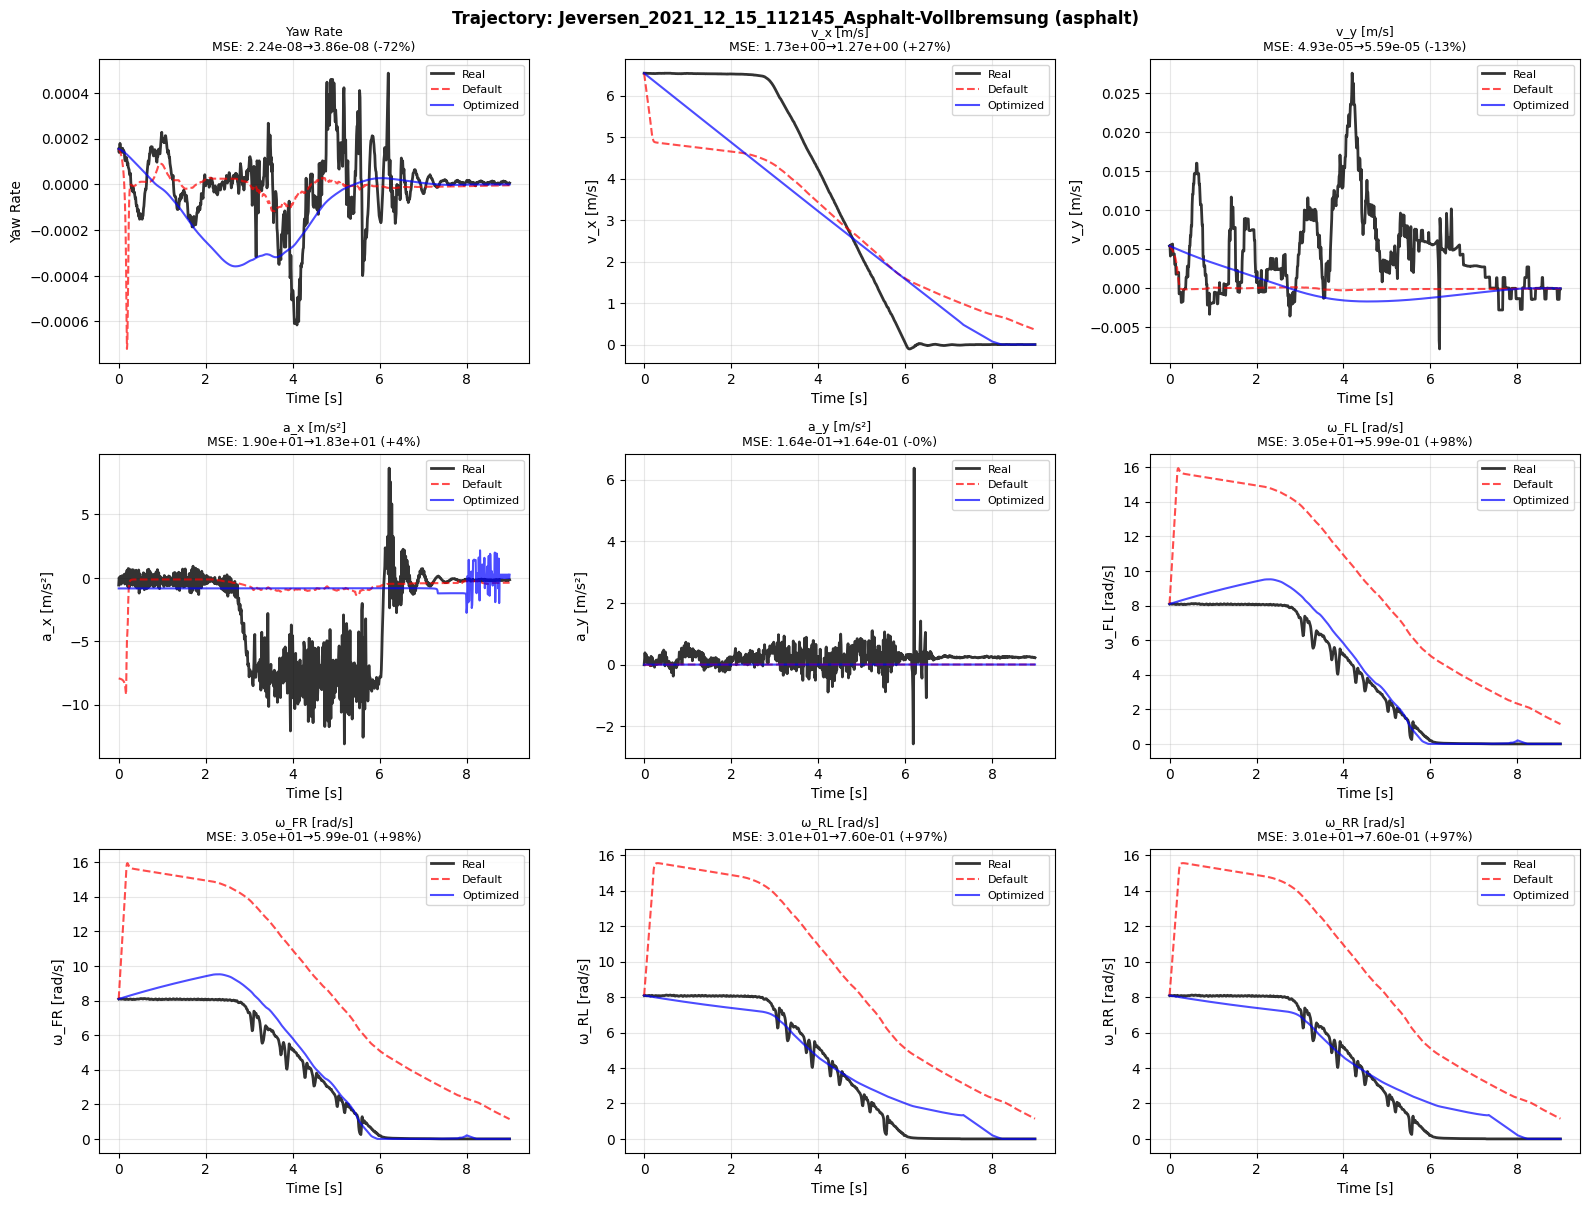

In [16]:
# Plot comparison for first trajectory
test_sim = simulations[0]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

time = np.arange(test_sim['T']) * 0.01
obs_labels = ["Yaw Rate", "v_x [m/s]", "v_y [m/s]", "a_x [m/s²]", "a_y [m/s²]",
              "ω_FL [rad/s]", "ω_FR [rad/s]", "ω_RL [rad/s]", "ω_RR [rad/s]"]

for i, label in enumerate(obs_labels):
    ax = axes[i]
    
    ax.plot(time, test_sim['y_real'][:, i], 'k-', lw=2, label='Real', alpha=0.8)
    ax.plot(time, test_sim['y_default'][:, i], 'r--', lw=1.5, label='Default', alpha=0.7)
    ax.plot(time, test_sim['y_opt'][:, i], 'b-', lw=1.5, label='Optimized', alpha=0.7)
    
    ax.set_xlabel('Time [s]')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Compute improvement
    mse_def = np.mean((test_sim['y_default'][:, i] - test_sim['y_real'][:, i])**2)
    mse_opt = np.mean((test_sim['y_opt'][:, i] - test_sim['y_real'][:, i])**2)
    imp = (mse_def - mse_opt) / mse_def * 100 if mse_def > 0 else 0
    ax.set_title(f'{label}\nMSE: {mse_def:.2e}→{mse_opt:.2e} ({imp:+.0f}%)', fontsize=9)

plt.tight_layout()
plt.suptitle(f'Trajectory: {test_sim["name"][:50]} ({test_sim["surface"]})',
             y=1.001, fontsize=12, fontweight='bold')
plt.show()

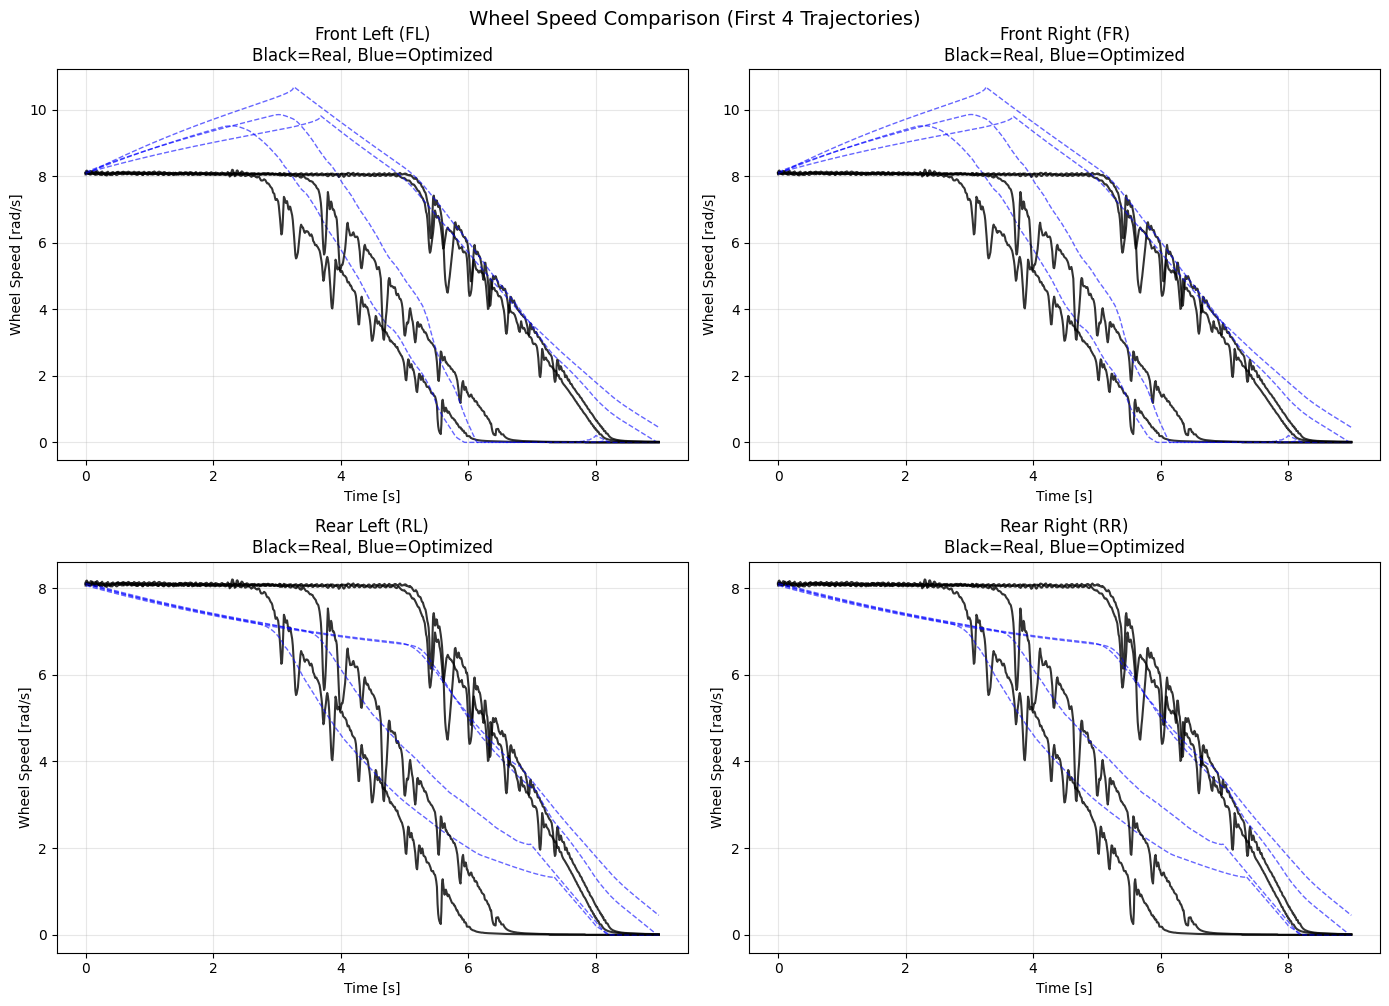

In [17]:
# Compare wheel speeds specifically (most important for braking)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

wheel_labels = ['Front Left (FL)', 'Front Right (FR)', 'Rear Left (RL)', 'Rear Right (RR)']
wheel_indices = [5, 6, 7, 8]  # Indices in observation vector

for ax, wlabel, widx in zip(axes.flatten(), wheel_labels, wheel_indices):
    for sim in simulations[:4]:  # Show first 4 trajectories
        time = np.arange(sim['T']) * 0.01
        ax.plot(time, sim['y_real'][:, widx], 'k-', lw=1.5, alpha=0.8)
        ax.plot(time, sim['y_opt'][:, widx], 'b--', lw=1, alpha=0.6)
    
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Wheel Speed [rad/s]')
    ax.set_title(f'{wlabel}\nBlack=Real, Blue=Optimized')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Wheel Speed Comparison (First 4 Trajectories)', y=1.001, fontsize=14)
plt.show()

## 8. Per-Trajectory Results

In [18]:
# Compute per-trajectory MSE
weights = jnp.array(CHANNEL_WEIGHTS)
results_per_traj = []

for traj, sim in zip(trajectories, simulations):
    # Default MSE
    sq_err_def = (sim['y_default'] - sim['y_real'])**2
    mse_def = float(np.mean(sq_err_def * np.array(weights)))
    
    # Optimized MSE
    sq_err_opt = (sim['y_opt'] - sim['y_real'])**2
    mse_opt = float(np.mean(sq_err_opt * np.array(weights)))
    
    improvement = (mse_def - mse_opt) / mse_def * 100
    
    results_per_traj.append({
        'name': traj['name'][:40],
        'surface': traj['surface'],
        'mse_default': mse_def,
        'mse_optimized': mse_opt,
        'improvement_pct': improvement,
    })

results_df = pd.DataFrame(results_per_traj)

print("\n" + "="*100)
print("PER-TRAJECTORY RESULTS (ALL 7 TRAJECTORIES)")
print("="*100)
print(results_df.to_string(index=False))

print("\n" + "="*100)
print("SUMMARY BY SURFACE TYPE")
print("="*100)
summary = results_df.groupby('surface').agg({
    'mse_default': 'mean',
    'mse_optimized': 'mean',
    'improvement_pct': 'mean'
}).round(4)
print(summary)

print(f"\nOverall Statistics:")
print(f"  Average improvement: {results_df['improvement_pct'].mean():.2f}% ± {results_df['improvement_pct'].std():.2f}%")
print(f"  Best trajectory: {results_df.loc[results_df['improvement_pct'].idxmax(), 'name'][:30]} ({results_df['improvement_pct'].max():.1f}%)")
print(f"  Worst trajectory: {results_df.loc[results_df['improvement_pct'].idxmin(), 'name'][:30]} ({results_df['improvement_pct'].min():.1f}%)")


PER-TRAJECTORY RESULTS (ALL 7 TRAJECTORIES)
                                    name  surface  mse_default  mse_optimized  improvement_pct
Jeversen_2021_12_15_112145_Asphalt-Vollb  asphalt    24.780676       1.038886        95.807678
Jeversen_2021_12_15_112328_Asphalt-Vollb  asphalt    32.103863       1.614365        94.971430
Jeversen_2021_12_15_125650_Beton-Vollbre concrete    25.690201       1.355327        94.724343
Jeversen_2021_12_15_125936_Beton-Vollbre concrete    30.991400       1.382341        95.539599
Jeversen_2021_12_15_134709_Basalt-Vollbr   basalt    20.307333       1.192666        94.126922
Jeversen_2021_12_15_134858_Basalt-Vollbr   basalt    22.891497       1.047448        95.424293
              Jeversen_2022_10_12_110132  unknown    20.234049       0.939257        95.358038

SUMMARY BY SURFACE TYPE
          mse_default  mse_optimized  improvement_pct
surface                                              
asphalt       28.4423         1.3266          95.3896
basalt  

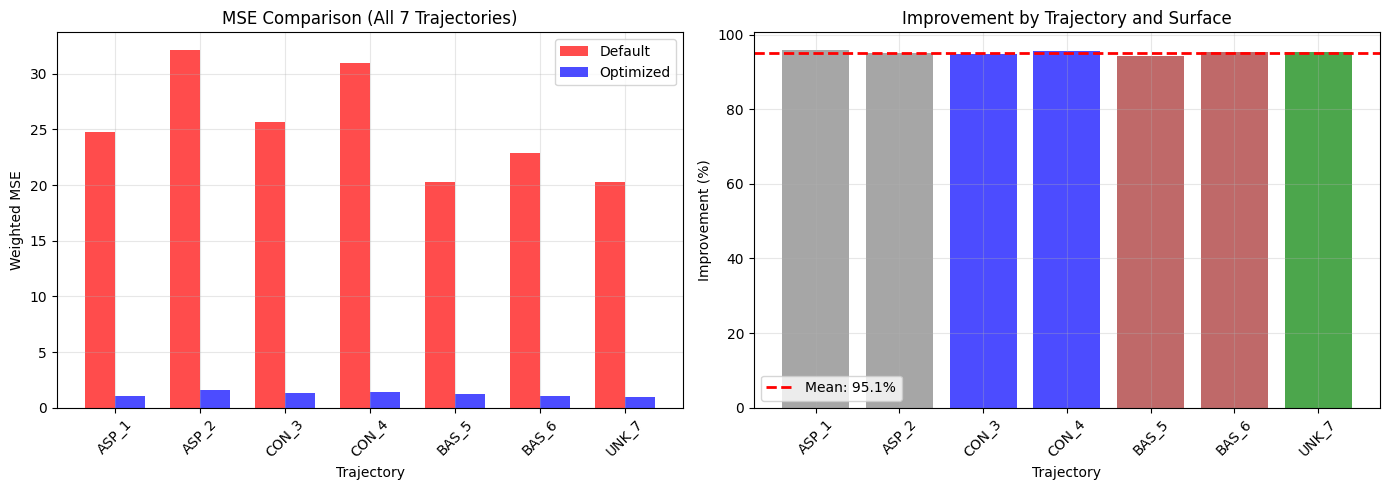

In [19]:
# Bar chart of improvements
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MSE comparison
x = np.arange(len(results_df))
width = 0.35
ax1.bar(x - width/2, results_df['mse_default'], width, label='Default', color='red', alpha=0.7)
ax1.bar(x + width/2, results_df['mse_optimized'], width, label='Optimized', color='blue', alpha=0.7)
ax1.set_xlabel('Trajectory')
ax1.set_ylabel('Weighted MSE')
ax1.set_title('MSE Comparison (All 7 Trajectories)')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{r['surface'][:3].upper()}_{i+1}" for i, r in results_df.iterrows()], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Improvement by surface
colors = {'asphalt': 'gray', 'concrete': 'blue', 'basalt': 'brown', 'unknown': 'green'}
bar_colors = [colors.get(s, 'gray') for s in results_df['surface']]
ax2.bar(x, results_df['improvement_pct'], color=bar_colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.axhline(y=results_df['improvement_pct'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {results_df["improvement_pct"].mean():.1f}%')
ax2.set_xlabel('Trajectory')
ax2.set_ylabel('Improvement (%)')
ax2.set_title('Improvement by Trajectory and Surface')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{r['surface'][:3].upper()}_{i+1}" for i, r in results_df.iterrows()], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Results

In [20]:
import json
from datetime import datetime

# Prepare comprehensive results
save_results = {
    'timestamp': datetime.now().isoformat(),
    'num_trajectories': len(trajectories),
    'trajectory_length': T_SEG,
    'num_parameters': len(PARAM_NAMES),
    'parameter_names': PARAM_NAMES,
    'channel_weights': CHANNEL_WEIGHTS.tolist(),
    'default_parameters': {name: float(PARAM_DEFAULTS[name]) for name in PARAM_NAMES},
    'optimized_parameters': {name: float(opt_params[i]) for i, name in enumerate(PARAM_NAMES)},
    'parameter_bounds': {name: list(PARAM_BOUNDS[name]) for name in PARAM_NAMES},
    'baseline_mse': float(baseline_mse),
    'optimized_mse': float(opt_mse),
    'improvement_pct': float((baseline_mse - opt_mse) / baseline_mse * 100),
    'per_trajectory_results': results_per_traj,
}

# Save JSON
output_path = Path("../experiments/advanced_parameter_estimation_results.json")
with open(output_path, 'w') as f:
    json.dump(save_results, f, indent=2)
print(f"✓ Results saved to: {output_path}")

# Save CSV
csv_path = Path("../experiments/advanced_parameter_estimation_results.csv")
results_df.to_csv(csv_path, index=False)
print(f"✓ Per-trajectory results saved to: {csv_path}")

✓ Results saved to: ..\experiments\advanced_parameter_estimation_results.json
✓ Per-trajectory results saved to: ..\experiments\advanced_parameter_estimation_results.csv


## 10. Final Summary and Configuration Update Recommendations

In [21]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n✓ Used ALL {len(trajectories)} trajectory files")
print(f"✓ Optimized {len(PARAM_NAMES)} parameters")
print(f"✓ Overall improvement: {(baseline_mse - opt_mse) / baseline_mse * 100:.1f}%")

print("\n" + "="*80)
print("RECOMMENDED UPDATES TO VehicleModel.py default_params:")
print("="*80)
print("\ndefault_params = {")
for name in ['c_1x', 'c_2x', 'c_1y', 'c_2y', 'C_x', 'C_y', 'E_x', 'E_y', 
             'C_roll1', 'C_roll2', 'mass', 'Inertia_z', 'Inertia_tire', 
             'Inertia_engine', 'air_resistance', 'dt']:
    if name in PARAM_NAMES:
        idx = PARAM_NAMES.index(name)
        val = opt_params[idx]
        comment = f"  # WAS: {PARAM_DEFAULTS[name]}"
    elif name == 'c_1y':
        val = original_default_params['c_1y']
        comment = ""
    elif name == 'c_2y':
        val = original_default_params['c_2y']
        comment = ""
    elif name == 'C_y':
        val = original_default_params['C_y']
        comment = ""
    elif name == 'E_y':
        val = original_default_params['E_y']
        comment = ""
    else:
        val = original_default_params[name]
        comment = ""
    
    if isinstance(val, float) and (abs(val) > 1e4 or abs(val) < 1e-2):
        print(f'    "{name}": {val:.4e},{comment}')
    else:
        print(f'    "{name}": {val:.6g},{comment}')
print("}")

print("\n" + "="*80)
print("NOTE: Also update radius_tire constant:")
print("="*80)
radius_idx = PARAM_NAMES.index('radius_tire')
print(f"radius_tire = {opt_params[radius_idx]:.6f}  # WAS: {original_radius_tire}")

print("\n" + "="*80)
print("For configs/config.py fixed parameter values:")
print("="*80)
mu_idx = PARAM_NAMES.index('mu')
cd_idx = PARAM_NAMES.index('cd')
mass_idx = PARAM_NAMES.index('mass')
print(f"fixed_mu: {opt_params[mu_idx]:.4f}")
print(f"fixed_cd: {opt_params[cd_idx]:.4f}")
print(f"fixed_m: {opt_params[mass_idx]:.1f}")


FINAL SUMMARY

✓ Used ALL 7 trajectory files
✓ Optimized 11 parameters
✓ Overall improvement: 95.2%

RECOMMENDED UPDATES TO VehicleModel.py default_params:

default_params = {
    "c_1x": 3.8651e+07,  # WAS: 25000000.0
    "c_2x": 2.5546e+05,  # WAS: 3600000.0
    "c_1y": 1.9000e+06,
    "c_2y": 1.3500e+05,
    "C_x": 1.8913,  # WAS: 1.42
    "C_y": 1.9,
    "E_x": -4.36307,  # WAS: -9.75
    "E_y": 0.52,
    "C_roll1": 0.0184632,  # WAS: 0.0083
    "C_roll2": 1.9958e-03,  # WAS: 0.0005
    "mass": 2174.57,  # WAS: 1720.0
    "Inertia_z": 2066,
    "Inertia_tire": 59.9982,  # WAS: 28.6
    "Inertia_engine": 0.197,
    "air_resistance": 0.27,
    "dt": 0.01,
}

NOTE: Also update radius_tire constant:
radius_tire = 0.353315  # WAS: 0.3116

For configs/config.py fixed parameter values:
fixed_mu: 0.4838
fixed_cd: 0.7571
fixed_m: 2174.6
